In [1]:
import os
import sys
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [2]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import warnings
warnings.filterwarnings('ignore')

In [3]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

with open(os.path.join("../config/model.yaml"), "r") as f:
    config_model = yaml.safe_load(f)

In [4]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['feature_eng'],
            "X_train_feat_eng_pipeline1.parquet"))
y_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['feature_eng'],
            "Y_train_feat_eng_pipeline1.parquet"))

In [5]:
X_train.drop(
            columns=config_model['single_model']['cols_2_drop'],
            inplace=True)
        
# X_val.drop(
#             columns=config_model['single_model']['cols_2_drop'],
#             inplace=True)   


In [7]:
sfs = SFS(
    estimator=LinearRegression(),
    k_features=X_train.shape[1]-1,  
    forward=True,  
    floating=False,  
    scoring='r2',
    cv=5, 
    n_jobs=-1
    )  

In [8]:
sfs_pipe = make_pipeline(sfs)
sfs_fit = sfs_pipe.fit(X_train, y_train)
    
results = pd.DataFrame.from_dict(sfs_pipe.named_steps['sequentialfeatureselector'].subsets_).T

In [9]:
results

,feature_idx,cv_scores,avg_score,feature_names
1,"(7,)","[0.6569709630519698, 0.6477522937176972, 0.655...",0.649235,"(num_dis_pipe__OverallQual,)"
2,"(1, 7)","[0.7733624439402175, 0.7052219963029969, 0.722...",0.741112,"(num_con_1_pipe__GrLivArea, num_dis_pipe__Over..."
3,"(1, 2, 7)","[0.8054117052590958, 0.7574301728822056, 0.749...",0.774111,"(num_con_1_pipe__GrLivArea, num_con_2_pipe__Bs..."
4,"(0, 1, 2, 7)","[0.8160692651736186, 0.7874796615663747, 0.762...",0.795042,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
5,"(0, 1, 2, 7, 14)","[0.8264226583255129, 0.8000159892986385, 0.775...",0.81043,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
6,"(0, 1, 2, 3, 7, 14)","[0.837866548289803, 0.801604731739917, 0.78553...",0.818928,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
7,"(0, 1, 2, 3, 6, 7, 14)","[0.8366565632451681, 0.8055989946299611, 0.807...",0.825795,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
8,"(0, 1, 2, 3, 6, 7, 12, 14)","[0.8459897257994939, 0.8124901032546276, 0.815...",0.832446,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
9,"(0, 1, 2, 3, 4, 6, 7, 12, 14)","[0.8484517532263923, 0.8159782088490057, 0.816...",0.835406,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
10,"(0, 1, 2, 3, 4, 5, 6, 7, 12, 14)","[0.8507622198013922, 0.8174887122839601, 0.817...",0.836632,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."


In [10]:
df_features = results['feature_names'].apply(pd.Series)

In [11]:
df = df_features.copy()

# substituir NaN por vazio
df = df.fillna('')

novos = []

linha_anterior = set()

for _, row in df.iterrows():
    valores_atuais = set([x for x in row if x != ''])
    
    # pega o que apareceu agora
    novo = valores_atuais - linha_anterior
    
    # transforma em texto
    novos.append(list(novo)[0] if len(novo) > 0 else None)
    
    # atualiza referência
    linha_anterior = valores_atuais

df['novo_texto'] = novos


In [12]:
df['score'] = results['avg_score']

In [13]:
df['score_diff'] = df['score'].diff()

In [14]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,novo_texto,score,score_diff
1,num_dis_pipe__OverallQual,,,,,,,,,,,,,,,,,num_dis_pipe__OverallQual,0.649235,NaN
2,num_con_1_pipe__GrLivArea,num_dis_pipe__OverallQual,,,,,,,,,,,,,,,,num_con_1_pipe__GrLivArea,0.741112,0.091877
3,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_dis_pipe__OverallQual,,,,,,,,,,,,,,,num_con_2_pipe__BsmtFinSF1,0.774111,0.032999
4,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_dis_pipe__OverallQual,,,,,,,,,,,,,,num_con_1_pipe__LotArea,0.795042,0.020931
5,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_dis_pipe__OverallQual,categorical_pipe__BsmtQual_TA,,,,,,,,,,,,,categorical_pipe__BsmtQual_TA,0.81043,0.015388
6,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_dis_pipe__OverallQual,categorical_pipe__BsmtQual_TA,,,,,,,,,,,,num_con_2_pipe__2ndFlrSF,0.818928,0.008499
7,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,categorical_pipe__BsmtQual_TA,,,,,,,,,,,num_con_2_pipe__GarageArea,0.825795,0.006867
8,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,categorical_pipe__ExterQual_TA,categorical_pipe__BsmtQual_TA,,,,,,,,,,categorical_pipe__ExterQual_TA,0.832446,0.006651
9,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,categorical_pipe__ExterQual_TA,categorical_pipe__BsmtQual_TA,,,,,,,,,num_con_2_pipe__WoodDeckSF,0.835406,0.00296
10,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__WoodDeckSF,num_con_2_pipe__OpenPorchSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,categorical_pipe__ExterQual_TA,categorical_pipe__BsmtQual_TA,,,,,,,,num_con_2_pipe__OpenPorchSF,0.836632,0.001226


In [15]:
metric_dict = sfs.get_metric_dict()
num_features = list(metric_dict.keys())
avg_scores = [metric_dict[k]['avg_score'] for k in num_features]
std_scores = [metric_dict[k]['std_dev'] for k in num_features]
cv_scores = [metric_dict[k]['cv_scores'] for k in num_features]  # Scores individuais de cada fold

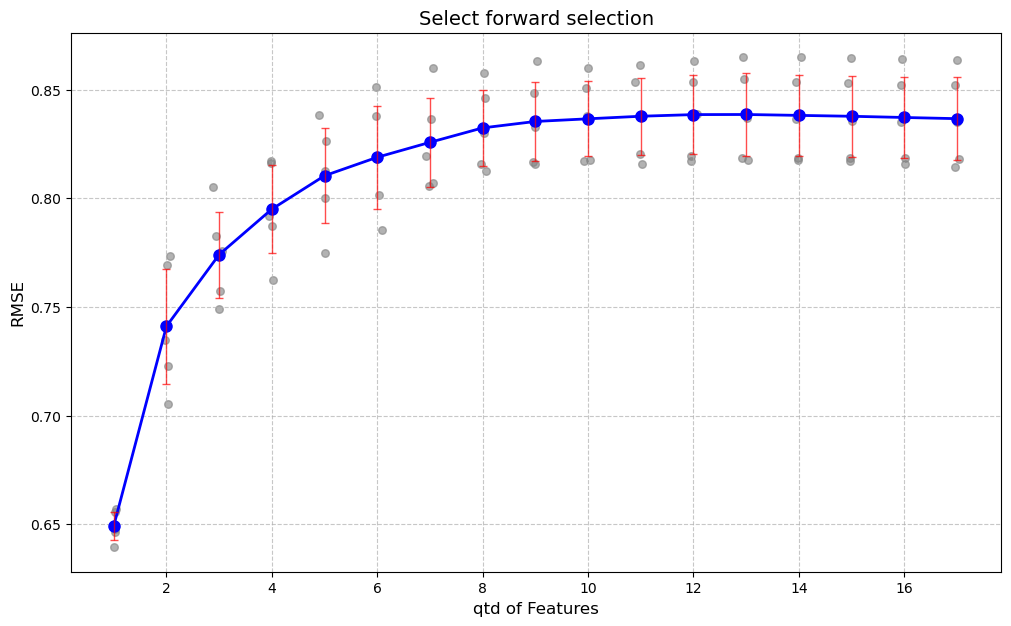

In [16]:
plt.figure(figsize=(12, 7))
plt.plot(
    num_features, 
    avg_scores, 
    marker='o', 
    linestyle='-', 
    color='b', 
    linewidth=2,
    markersize=8)

# Adicionar barras de erro (desvio padrão)
plt.errorbar(
    num_features, 
    avg_scores, 
    yerr=std_scores, 
    fmt='none', 
    ecolor='red', 
    elinewidth=1, 
    capsize=3, 
    alpha=0.7)

# Adicionar pontos individuais de cada fold da validação cruzada
for i, n in enumerate(num_features):
    # Espalhar os pontos horizontalmente para melhor visualização
    x_positions = np.random.normal(n, 0.05, size=len(cv_scores[i]))
    plt.scatter(x_positions, cv_scores[i], color='gray', alpha=0.6, s=30)

plt.xlabel('qtd of Features', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Select forward selection', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
